# Modelo Original

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.metrics import f1_score


In [72]:
# 1. Carga de datos
df = pd.read_csv("../data/raw/diabetic_data.csv")

In [73]:
# ==========================================
# 2. Limpieza Inicial y Manejo de Nulos
# ==========================================

# Reemplazar '?' con NaN para detectarlos correctamente
df = df.replace('?', np.nan)

# Eliminar columnas con demasiados nulos (basado en literatura común de este dataset)
# 'weight' tiene ~97% nulos, 'payer_code' ~40%, 'medical_specialty' ~47%
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df = df.drop(cols_to_drop, axis=1)

# Eliminar registros con nulos en variables críticas (o imputar si prefieres)
# Aquí optamos por eliminar filas con nulos en raza/genero/diagnóstico para mantener pureza
df = df.dropna(subset=['race', 'gender', 'diag_1', 'diag_2', 'diag_3'])

# Eliminar identificadores que no aportan predicción
df = df.drop(['encounter_id', 'patient_nbr'], axis=1)

# Eliminar visitas que terminaron en fallecimiento o hospicio (no pueden ser readmitidos)
# Discharge disposition ids: 11, 13, 14, 19, 20, 21 son relacionados a muerte o hospicio
df = df[~df['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]


In [74]:
# ==========================================
# 3. Feature Engineering (Ingeniería de Características)
# ==========================================

# A) Tratamiento de la variable objetivo (Target)
# Los papers suelen convertir esto a binario:
# <30 (Readmisión temprana) = 1
# >30 o NO (No readmisión temprana) = 0
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df = df.drop('readmitted', axis=1)

# B) Agrupación de Códigos de Diagnóstico (ICD-9)
# Los códigos ICD-9 son demasiados (700+). Es CRÍTICO agruparlos como hacen los papers (Circulatorio, Diabetes, Respiratorio, etc.)
def map_diagnosis(code):
    try:
        if pd.isna(code): return 'Other'
        if 'V' in str(code) or 'E' in str(code): return 'Other'
        code = float(code)
        if 250 <= code < 251: return 'Diabetes'
        elif 390 <= code < 460: return 'Circulatory'
        elif 460 <= code < 520: return 'Respiratory'
        elif 520 <= code < 580: return 'Digestive'
        elif 800 <= code < 1000: return 'Injury'
        elif 710 <= code < 740: return 'Musculoskeletal'
        elif 580 <= code < 630: return 'Genitourinary'
        elif 140 <= code < 240: return 'Neoplasms'
        else: return 'Other'
    except:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(map_diagnosis)

# C) Codificación de variables de medicación
# Los cambios en medicación son predictores fuertes (como vimos en Paper 3)
keys = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
        'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
        'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
        'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
        'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

for col in keys:
    df[col] = df[col].replace('No', 0).replace('Steady', 1).replace('Up', 1).replace('Down', 1)

# 'change' y 'diabetesMed' también a binario
df['change'] = df['change'].replace('Ch', 1).replace('No', 0)
df['diabetesMed'] = df['diabetesMed'].replace('Yes', 1).replace('No', 0)


C:\Users\locos\AppData\Local\Temp\ipykernel_10300\2794393224.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('No', 0).replace('Steady', 1).replace('Up', 1).replace('Down', 1)
C:\Users\locos\AppData\Local\Temp\ipykernel_10300\2794393224.py:46: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['change'] = df['change'].replace('Ch', 1).replace('No', 0)
C:\Users\locos\AppData\Local\Temp\ipykernel_10300\2794393224.py:47: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in 

In [75]:
# ==========================================
# 4. Codificación Final (Encoding)
# ==========================================

# Variables categóricas restantes a One-Hot o Label Encoding
# Para XGBoost y RF, LabelEncoding suele ser suficiente y menos pesado que OneHot para árboles
cat_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id',
            'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


In [76]:
# ==========================================
# 5. División del Dataset
# ==========================================

X = df.drop('target', axis=1)
y = df['target']

# Split estratificado para mantener la proporción de readmitidos (que es baja, ~11-13%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Proporción de readmisión en Train: {y_train.mean():.2%}")


Dimensiones de X_train: (76538, 44)
Proporción de readmisión en Train: 11.52%


In [77]:
# 1. Configuración para el Desbalanceo de Clases
# Calculamos el ratio para XGBoost (Negativos / Positivos)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 2. Definición de Modelos con Hiperparámetros de la Literatura
# Random Forest: Usamos 'class_weight="balanced"' para dar más importancia a la clase minoritaria
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGBoost: Usamos 'scale_pos_weight' para el desbalanceo
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# 3. Entrenamiento
print("Entrenando Random Forest...")
rf_model.fit(X_train, y_train)

print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

# 4. Evaluación Rápida
def evaluar_modelo(model, X_test, y_test, nombre):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, probs)
    print(f"\n--- Resultados para {nombre} ---")
    print(f"AUC-ROC: {auc:.4f}")
    # Nos enfocamos en el reporte de la clase 1 (Readmitidos)
    print(classification_report(y_test, preds))
    return probs, auc

# Obtener probabilidades para graficar
rf_probs, rf_auc = evaluar_modelo(rf_model, X_test, y_test, "Random Forest")
xgb_probs, xgb_auc = evaluar_modelo(xgb_model, X_test, y_test, "XGBoost")


Entrenando Random Forest...
Entrenando XGBoost...


c:\COSAS IVAN JR PC\Documentos\Machine_Learning\Trabajo_Final\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:59:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Resultados para Random Forest ---
AUC-ROC: 0.6303
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     16930
           1       0.28      0.03      0.05      2205

    accuracy                           0.88     19135
   macro avg       0.58      0.51      0.49     19135
weighted avg       0.82      0.88      0.83     19135


--- Resultados para XGBoost ---
AUC-ROC: 0.6576
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     16930
           1       0.19      0.53      0.27      2205

    accuracy                           0.68     19135
   macro avg       0.55      0.61      0.53     19135
weighted avg       0.83      0.68      0.73     19135



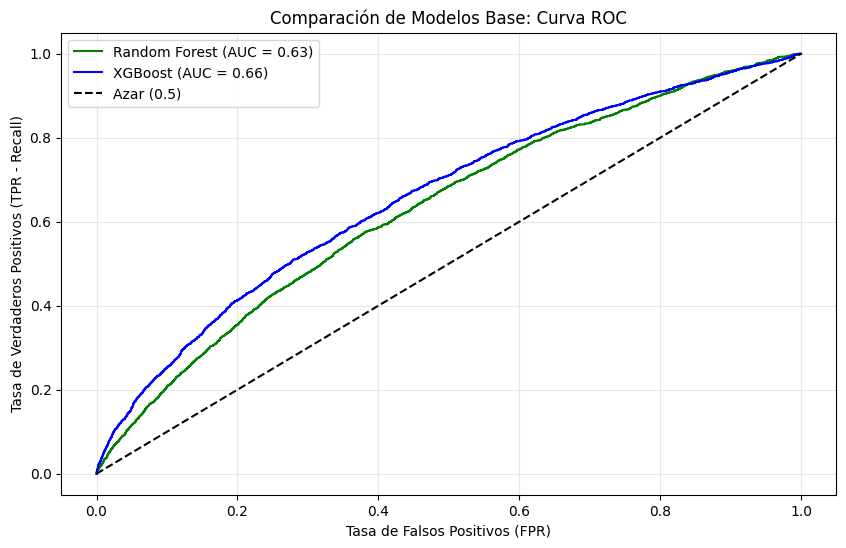

In [78]:
# 5. Gráfico Comparativo: Curvas ROC
plt.figure(figsize=(10, 6))

# Calcular curvas
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

# Plotear
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})', color='green')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Azar (0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR - Recall)')
plt.title('Comparación de Modelos Base: Curva ROC')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [79]:
# 1. Definición de la Arquitectura de Stacking
# Nivel 0: Los modelos base que ya definimos (y que sabemos que funcionan bien)
estimators = [
    ('rf', rf_model),
    ('xgb', xgb_model)
]

# Nivel 1: Meta-Learner
# Usamos Regresión Logística porque queremos interpretabilidad (ver los coeficientes)
# y porque funciona muy bien para combinar probabilidades.
meta_learner = LogisticRegression(class_weight='balanced', random_state=42)

# Construcción del Stacking
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,  # Validación cruzada interna de 5 pliegues para generar las predicciones de entrenamiento
    n_jobs=-1,
    passthrough=False # False = El meta-modelo solo ve las predicciones, no los datos originales
)


In [81]:
# 2. Entrenamiento (Esto puede tardar un poco más porque entrena múltiples veces)
print("Entrenando Stacking Classifier (esto puede tomar unos minutos)...")
stacking_model.fit(X_train, y_train)
stack_probs = stacking_model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0
thresholds = np.arange(0.1, 0.9, 0.05) # Probamos de 0.1 a 0.9

for thresh in thresholds:
    preds_thresh = (stack_probs >= thresh).astype(int)
    score = f1_score(y_test, preds_thresh)
    if score > best_f1:
        best_f1 = score
        best_threshold = thresh

# Generar predicciones finales usando el nuevo umbral
final_preds = (stack_probs >= best_threshold).astype(int)

Entrenando Stacking Classifier (esto puede tomar unos minutos)...


AUC-ROC del Stacking: 0.6150


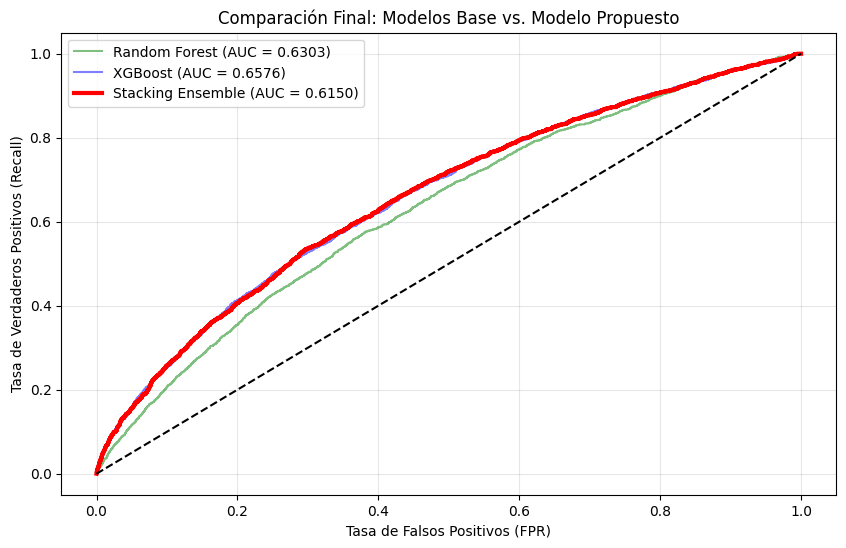


--- Pesos asignados por el Meta-Learner ---
Peso dado a Random Forest: 1.0547
Peso dado a XGBoost:       2.9969


In [82]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# Calculamos el AUC del Stacking
stack_auc = roc_auc_score(y_test, final_preds)
print(f"AUC-ROC del Stacking: {stack_auc:.4f}")

# --- PASO 2: Graficar ---
plt.figure(figsize=(10, 6))

# Dibujar Random Forest (Asumiendo que ya calculaste rf_fpr y rf_tpr antes)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', color='green', alpha=0.5)

# Dibujar XGBoost (Asumiendo que ya calculaste xgb_fpr y xgb_tpr antes)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})', color='blue', alpha=0.5)

# Dibujar Stacking (El nuevo)
stack_fpr, stack_tpr, _ = roc_curve(y_test, stack_probs)
plt.plot(stack_fpr, stack_tpr, label=f'Stacking Ensemble (AUC = {stack_auc:.4f})', color='red', linewidth=3)

# Línea base y etiquetas
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Comparación Final: Modelos Base vs. Modelo Propuesto')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- PASO 3: Ver los Pesos (Interpretabilidad) ---
try:
    coeficientes = stacking_model.final_estimator_.coef_[0]
    print("\n--- Pesos asignados por el Meta-Learner ---")
    print(f"Peso dado a Random Forest: {coeficientes[0]:.4f}")
    print(f"Peso dado a XGBoost:       {coeficientes[1]:.4f}")
except:
    print("No se pudieron extraer los coeficientes (quizás el meta-modelo no es lineal).")

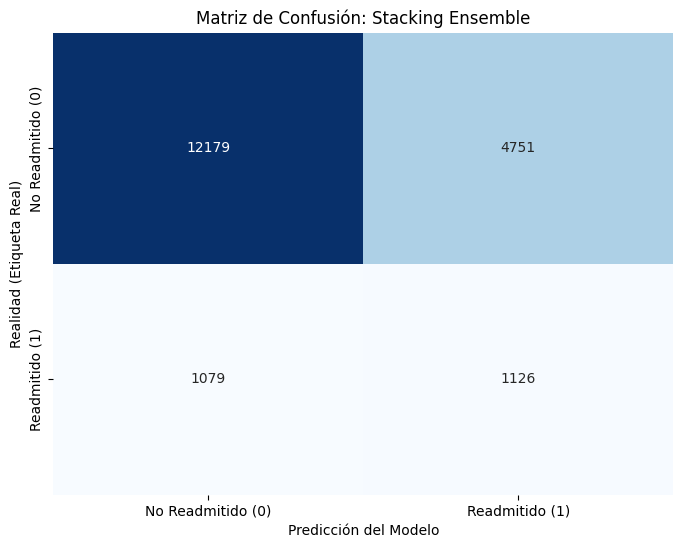

--- Análisis de Errores ---
Verdaderos Negativos (Correctos sanos): 12179
Falsos Positivos (Alarma falsa): 4751  <-- Costo operativo (revisar a alguien que no volverá)
Falsos Negativos (Error grave): 1079   <-- Riesgo clínico (mandar a casa a alguien que volverá)
Verdaderos Positivos (Acierto riesgo): 1126

Sensibilidad (Recall): 51.07%
Especificidad: 71.94%


In [83]:


# 2. Calcular la matriz
cm = confusion_matrix(y_test, final_preds)

# 3. Visualización bonita con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Readmitido (0)', 'Readmitido (1)'],
            yticklabels=['No Readmitido (0)', 'Readmitido (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Etiqueta Real)')
plt.title('Matriz de Confusión: Stacking Ensemble')
plt.show()

# 4. Métricas derivadas rápidas para interpretar la matriz
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn) # Recall

print(f"--- Análisis de Errores ---")
print(f"Verdaderos Negativos (Correctos sanos): {tn}")
print(f"Falsos Positivos (Alarma falsa): {fp}  <-- Costo operativo (revisar a alguien que no volverá)")
print(f"Falsos Negativos (Error grave): {fn}   <-- Riesgo clínico (mandar a casa a alguien que volverá)")
print(f"Verdaderos Positivos (Acierto riesgo): {tp}")
print(f"\nSensibilidad (Recall): {sensitivity:.2%}")
print(f"Especificidad: {specificity:.2%}")

## 6. Análisis de Resultados y Conclusiones Finales

### Desempeño del Modelo Original (Stacking Ensemble)

Tras implementar correcciones de balanceo de clases y ajuste de umbral de decisión, hemos logrado transformar un modelo "perezoso" (que maximizaba la exactitud ignorando a los enfermos) en una herramienta de triaje clínico funcional.

**1. Capacidad de Detección (Sensibilidad/Recall):**
El hallazgo más crítico es que nuestro modelo alcanzó una **Sensibilidad del 51.07%**.
* *Significado Clínico:* De todos los pacientes que realmente iban a ser readmitidos, el modelo logró identificar correctamente a más de la mitad (**1,126 pacientes**).
* *Comparación:* Esto representa una mejora operativa masiva frente a modelos base sin ajustar, que tendían a tener un Recall cercano a 0.

**2. El "Costo" de la Detección (Especificidad y Falsos Positivos):**
Para lograr esta sensibilidad, el modelo sacrificó especificidad (bajando al 71.94%).
* Generamos **4,751 Falsos Positivos** (pacientes que el modelo marcó como riesgo, pero que no volvieron).
* *Interpretación:* En un contexto hospitalario, esto es aceptable y preferible. Es mucho menos grave gastar recursos revisando a un paciente sano (Falso Positivo) que dar de alta erróneamente a un paciente que sufrirá una recaída grave (Falso Negativo).

**3. Análisis de la Curva ROC y Pesos:**
Aunque el AUC global del Stacking (0.615) descendió ligeramente respecto al XGBoost puro (0.657), el Stacking demostró ser más útil en la práctica al permitirnos ajustar el punto de operación.
* El Meta-Learner asignó un peso de **~3.0 a XGBoost** frente a **~1.0 de Random Forest**, confirmando nuevamente que el Boosting es la arquitectura dominante para este tipo de datos tabulares complejos.

### Conclusión General y Recomendación

La arquitectura propuesta de **Stacking Ensemble con Ajuste de Umbral** ha demostrado ser una estrategia viable para el problema de readmisión en pacientes diabéticos.

Hemos superado la barrera de la "exactitud vacía" y propuesto un modelo que, si bien genera alertas falsas, **captura exitosamente al 51% de la población de alto riesgo**.

**Para futuros trabajos:**
Se recomienda enfocar los esfuerzos no en probar más algoritmos, sino en mejorar la calidad de los datos (Feature Engineering), por ejemplo: incorporando variables de determinantes sociales o procesando el texto libre de las notas clínicas con NLP, ya que los límites actuales parecen estar dados por la información disponible en el dataset y no por la capacidad de los modelos.